In [93]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

import torch.nn as nn
import torch

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

In [94]:
# Device-agnostic code

if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

print(f"device : {DEVICE}") # my device isn't allowing the gpu for some reason ;(

device : cpu


In [95]:
# Data loading
df = pd.read_csv('../Data/Training Set filtered.csv')

df.columns = df.columns.str.strip()

df.head

<bound method NDFrame.head of                   Datetime  Export  Import  Generation  National Load  \
0      01/10/2025 05:45:00     0.0  320.38     1157.64        1478.02   
1      01/10/2025 06:00:00     0.0  329.78     1175.98        1505.76   
2      01/10/2025 06:15:00     0.0  377.45     1221.01        1598.46   
3      01/10/2025 06:30:00     0.0  403.71     1231.19        1636.49   
4      01/10/2025 06:45:00     0.0  369.32     1279.29        1648.61   
...                    ...     ...     ...         ...            ...   
37732                  NaN     NaN     NaN         NaN        1284.43   
37733                  NaN     NaN     NaN         NaN        1284.43   
37734                  NaN     NaN     NaN         NaN        1284.43   
37735                  NaN     NaN     NaN         NaN        1284.43   
37736                  NaN     NaN     NaN         NaN        1284.43   

       System Load  Bhairahawa_Temperature (at 2m), C  \
0          1478.02                  

In [96]:
# Small cleanups
df['Datetime'] = pd.to_datetime(df['Datetime'], format = '%m/%d/%Y %H:%M:%S')

# Dropping the NaT trailing rows in Datetime
# df = df.dropna(subset = ['Datetime']).copy()

df = df.dropna()

In [97]:
# Feature engineering
hour_float = df['Datetime'].dt.hour + df['Datetime'].dt.minute / 60
df['sin_hour'] = np.sin(2 * np.pi * hour_float / 24)
df['cos_hour'] = np.cos(2 * np.pi * hour_float / 24)
df['sin_dow'] = np.sin(2 * np.pi * df['Datetime'].dt.dayofweek / 7)
df['cos_dow'] = np.cos(2 * np.pi * df['Datetime'].dt.dayofweek / 7)

In [98]:
# Defining targets

TARGET_COL = "National Load"
FEATURE_COLS = [c for c in df.columns if (c!= 'Datetime' and c!= 'is_outlier')] # using everything
TARGET_IDX = FEATURE_COLS.index(TARGET_COL)
INPUT_DIM = len(FEATURE_COLS)



In [99]:
# Hyperparameters

SEQ_LEN = 96
BATCH_SIZE = 64
HIDDEN_DIM = 64 # 128 is showing overfit. 64 ma test garam
NUM_LAYERS = 1 # Also reducing the number of layers from 2 to 1
DROPOUT = 0.3 # 0.2 bata 0.3 rakhera testinggg
LR = 1e-3
EPOCHS = 50 # 50 lai 100 banaidiye -> teslai feri 50 banaidiye since teti improvement nai vako xaina past 50 so I'm just wasting time here.
TRAIN_FRAC = 0.8 # 80 20 split

In [100]:
# Datasplitting

data = df[FEATURE_COLS].values
split = int(len(data) * TRAIN_FRAC)

train_raw, test_raw = data[:split], data[split:]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_raw)
test_scaled = scaler.transform(test_raw)

In [101]:
# Dataloading

class TimeSeriesDataset(Dataset):
    def __init__(self, data: np.ndarray, seq_len: int, target_idx: int):
        self.data = torch.tensor(data, dtype = torch.float32)
        self.seq_len = seq_len
        self.target_idx = target_idx

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_len]
        y = self.data[idx + self.seq_len, self.target_idx]
        return x, y


train_ds = TimeSeriesDataset(train_scaled, SEQ_LEN, TARGET_IDX)
test_ds = TimeSeriesDataset(test_scaled, SEQ_LEN, TARGET_IDX)

train_loader = DataLoader(train_ds, batch_size = BATCH_SIZE, shuffle = True, drop_last=True)
test_loader = DataLoader(test_ds, batch_size = BATCH_SIZE, shuffle = True)

xb, yb = next(iter(train_loader))
print(f'Batch X: {xb.shape} (batch, seq_len, features)')
print(f'Batch y: {yb.shape} (batch)')

Batch X: torch.Size([64, 96, 37]) (batch, seq_len, features)
Batch y: torch.Size([64]) (batch)


In [102]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout = 0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size = input_dim,
            hidden_size = hidden_dim,
            num_layers = num_layers,
            batch_first = True,
            dropout = dropout if num_layers > 1 else 0.0,
        )


        # Small MLP head for non-linear mapping from hiddle state -> prediction
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )


    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        return self.head(last).squeeze(-1)


model = LSTMForecaster(INPUT_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(DEVICE)
print(model)
print(f"\nTrainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}") # I feel like we are risking overfitting after seeing this result but idk man.

LSTMForecaster(
  (lstm): LSTM(37, 64, batch_first=True)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)

Trainable parameters: 28,481


In [103]:
# Training loop

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = LR, weight_decay = 1e-4) # adding weight decay since it apparently helps manage overfitting 
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode = 'min', patience = 5, factor = 0.5
)

train_losses, val_losses = [], []

best_val, best_state = float('inf'), None

for epoch in range(1, EPOCHS + 1):
    model.train()
    running = 0.0 
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running += loss.item() * len(xb)
    train_loss = running / len(train_ds)

    # Validate
    model.eval()
    val_running = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            preds = model(xb.to(DEVICE)).cpu()
            val_running += criterion(preds, yb).item() * len(xb)
    val_loss = val_running / len(test_ds)

    scheduler.step(val_loss)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val:
        best_val = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d} / {EPOCHS} Train MSE: {train_loss:.6f} Val MSE: {val_loss:.6f}')

model.load_state_dict(best_state)
print(f'\nBest val MSE: {best_val:.6f}')

Epoch   1 / 50 Train MSE: 0.011210 Val MSE: 0.002223
Epoch  10 / 50 Train MSE: 0.000367 Val MSE: 0.000783
Epoch  20 / 50 Train MSE: 0.000317 Val MSE: 0.000978
Epoch  30 / 50 Train MSE: 0.000306 Val MSE: 0.001049
Epoch  40 / 50 Train MSE: 0.000297 Val MSE: 0.000990
Epoch  50 / 50 Train MSE: 0.000295 Val MSE: 0.000994

Best val MSE: 0.000742


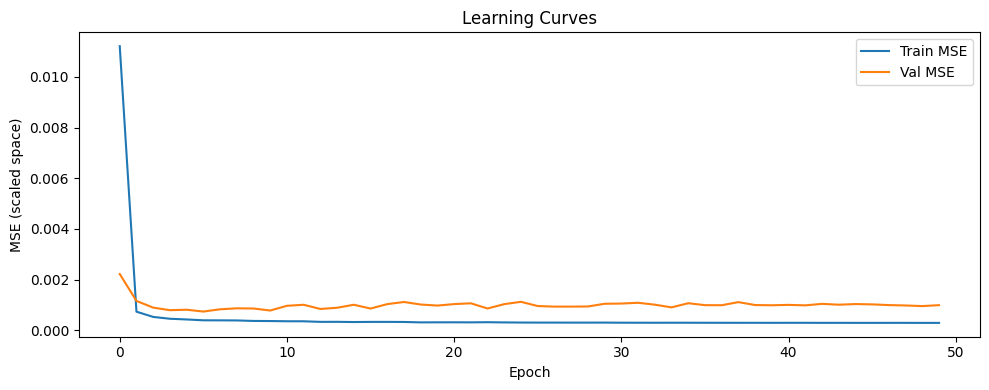

In [104]:
plt.figure(figsize = (10, 4))
plt.plot(train_losses, label = 'Train MSE')
plt.plot(val_losses, label = 'Val MSE')
plt.xlabel('Epoch')
plt.ylabel('MSE (scaled space)')
plt.title('Learning Curves')
plt.legend()
plt.tight_layout()
plt.show()

In [107]:
# evaluating the model

model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        preds = model(xb.to(DEVICE)).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(yb.numpy())

all_preds = np.array(all_preds)
all_true = np.array(all_true)

def inverse_target(scaled_vals, scaler, target_idx, n_features):
    dummy = np.zeros((len(scaled_vals), n_features))
    dummy[:, target_idx] = scaled_vals
    return scaler.inverse_transform(dummy)[:, target_idx]

preds_mw = inverse_target(all_preds, scaler, TARGET_IDX, INPUT_DIM)
true_mw = inverse_target(all_true, scaler, TARGET_IDX, INPUT_DIM)

mae = mean_absolute_error(true_mw, preds_mw)
mape = mean_absolute_percentage_error(true_mw, preds_mw) * 100 # only checking these for now

print(f'mae: {mae}')
print(f'mape: {mape}')

mae: 32.2700705980218
mape: 2.0068863504109746


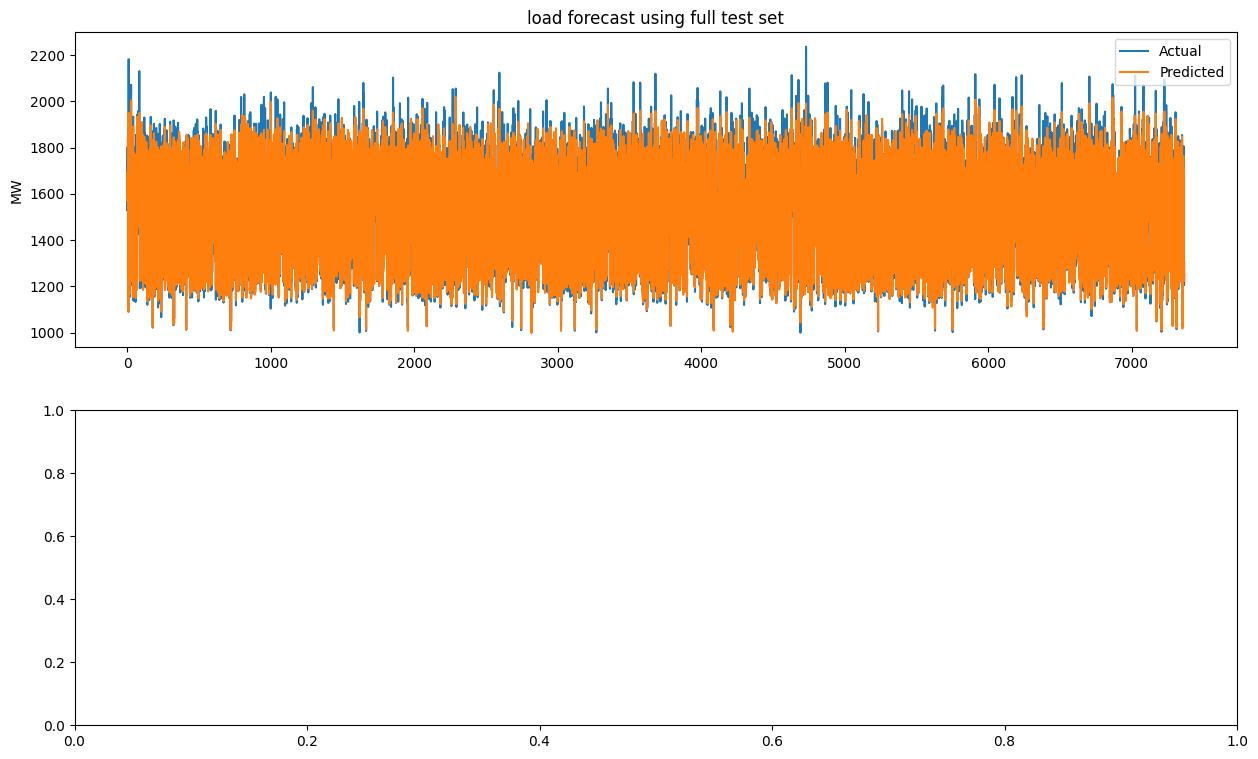

In [ ]:
# trying to plot the output

n_plot = 96

fig, axes = plt.subplots(2, 1, figsize = (15, 9))

axes[0].plot(true_mw, label = 'Actual')
axes[0].plot(preds_mw, label = 'Predicted')
axes[0].set_title("load forecast using full test set")
axes[0].set_ylabel("MW")
axes[0].legend()

axes[1].plot(true_mw[:n_plot], label = 'Actual')
axes[1].plot(preds_mw[:n_plot], label = 'Predicted')
axes[1].set_title("Predicting for the first day")
axes[1].set_xlabel("15-min intervals")
axes[1].set_ylabel("MW")
axes[1].legend()

plt.tight_layout()
plt.show()